## Задание
Эксперимент проходил с 2025-11-21 по 2025-11-27 включительно. Для эксперимента были задействованы 2 и 1 группы. 

В группе 2 был использован один из новых алгоритмов рекомендации постов, группа 1 использовалась в качестве контроля. 

Основная гипотеза заключается в том, что новый алгоритм во 2-й группе приведет к увеличению CTR. 

Задача — проанализировать данные А/B-теста. 

Выбрать метод анализа и сравнить CTR в двух группах ( t-тест, Пуассоновский бутстреп, тест Манна-Уитни, t-тест на сглаженном ctr (α=5) а также t-тест и тест Манна-Уитни поверх бакетного преобразования).

In [1]:
import pandas as pd
import pandahouse as ph
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")  # Настройка стиля графика
from scipy.stats import mannwhitneyu

In [2]:
connection = {'host': 'http://clickhouse.lab.karpov.courses:8123',
'database':'simulator_20251220',
'user':'student',
'password':'dpo_python_2020'
}

In [3]:
q = """SELECT uniqExact (user_id)
FROM simulator_20251220.feed_actions
WHERE toDate(time) >= '2025-11-21' and toDate(time) <= '2025-11-27'
"""

In [4]:
ph.read_clickhouse(q, connection=connection)

,uniqExact(user_id)
0,49814


In [5]:
q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251220.feed_actions 
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (2,1)
GROUP BY exp_group, user_id
"""

In [6]:
df = ph.read_clickhouse(q, connection=connection)

In [7]:
df.groupby('exp_group').count()

,user_id,likes,views,ctr
exp_group,,,,
1,10020,10020,10020,10020
2,9877,9877,9877,9877


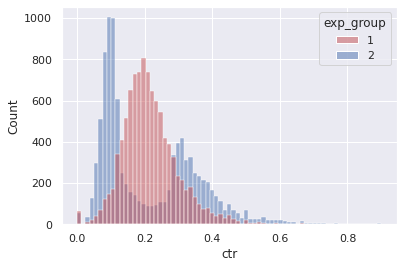

In [8]:
# Сделаем графики в seaborn покрупнее
sns.set(rc={'figure.figsize':(11.7,8.27)})

groups = sns.histplot(data = df, 
              x='ctr', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

 Ttest

In [9]:
stats.ttest_ind(df[df.exp_group == 1].ctr,
                df[df.exp_group == 2].ctr,
                equal_var=False)


Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)

 Ttest - Результат незначим, различий между группами нет: Значение 0.405 близко к нулю, что означает:

Разница между средними значениями групп очень мала; 
Распределение 2 группы  бимодальное! Из-за чего Ttest мог показать неверный результат!

## Критерий Манна-Уитни

In [10]:
stats.mannwhitneyu(df[df.exp_group == 1].ctr, 
                   df[df.exp_group == 2].ctr,
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

Mannwhitneyu - Более устойчив к выбросам и не требует предположения о нормальности данных.Существует статистически значимое различие в распределениях групп 1 и 2.


## Сглаженный CTR

In [11]:
def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr


In [12]:
q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251220.feed_actions 
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (1,2)
GROUP BY exp_group, user_id
"""

In [13]:
df = ph.read_clickhouse(q, connection=connection)

In [14]:
df

,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750
...,...,...,...,...,...
19892,2,17146,0,10,0.000000
19893,1,30872,11,59,0.186441
19894,2,25383,42,127,0.330709
19895,2,139020,17,41,0.414634


In [15]:
global_ctr_1 = df[df.exp_group == 1].likes.sum()/df[df.exp_group == 1].views.sum()
global_ctr_2 = df[df.exp_group == 2].likes.sum()/df[df.exp_group == 2].views.sum()

/tmp/ipykernel_272/890721516.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group1.ctr,


<Axes: xlabel='ctr'>

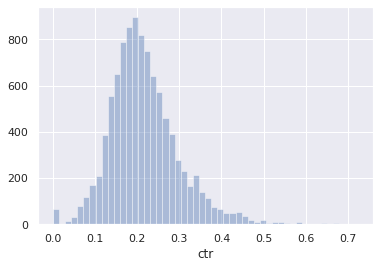

In [16]:
group1 = df[df.exp_group == 1].copy()
sns.distplot(group1.ctr, 
             kde = False)

In [17]:
group1['smothed_ctr'] = df.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)


/tmp/ipykernel_272/3943109957.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group1.smothed_ctr,


<Axes: xlabel='smothed_ctr'>

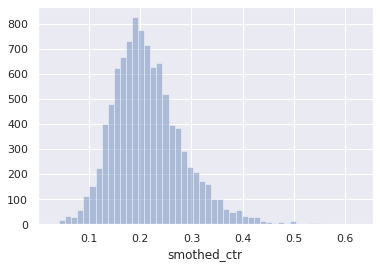

In [18]:
sns.distplot(group1.smothed_ctr, 
             kde = False)
#сглаженный CTR

/tmp/ipykernel_272/1661779519.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group1.ctr,


<Axes: xlabel='ctr'>

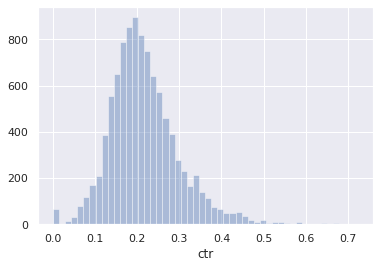

In [19]:
group2 = df[df.exp_group == 2].copy()
sns.distplot(group1.ctr, 
             kde = False)

In [20]:
group2['smothed_ctr'] = df.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1)



/tmp/ipykernel_272/3288336398.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group2.smothed_ctr,


<Axes: xlabel='smothed_ctr'>

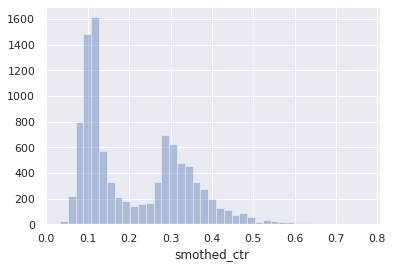

In [21]:
sns.distplot(group2.smothed_ctr, 
             kde = False)
#сглаженный CTR

ttest

In [22]:
stats.ttest_ind(group1['smothed_ctr'],
                group2['smothed_ctr'],
                equal_var=False)

Ttest_indResult(statistic=1.2447034376197381, pvalue=0.2132595139150962)

pvalue=0.21 - Нет достаточных доказательств, чтобы утверждать, что средние значения двух групп действительно различаются. Наблюдаемая разница (если она есть) может быть просто случайной

In [23]:
stats.mannwhitneyu(group1['smothed_ctr'],
                group2['smothed_ctr'],
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=55331333.5, pvalue=3.1197590812268766e-47)

Сравнение с предыдущим t-тестом: противоречивые результаты:

t-тест: p=0.213 → нет значимых различий средних

Mannwhitneyu: p≈0 → есть значимые различия распределений

## Пуассоновский бутстреп

In [24]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):

    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2

In [25]:
q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251220.feed_actions 
WHERE toDate(time) between '2025-11-21' and '2025-11-27'
    and exp_group in (1,2)
GROUP BY exp_group, user_id
"""

In [26]:
df = ph.read_clickhouse(q, connection=connection)

In [27]:
likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()

In [28]:
ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

<Axes: ylabel='Count'>

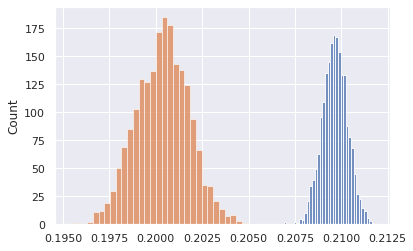

In [29]:
sns.histplot(ctr1)
sns.histplot(ctr2)

<Axes: ylabel='Count'>

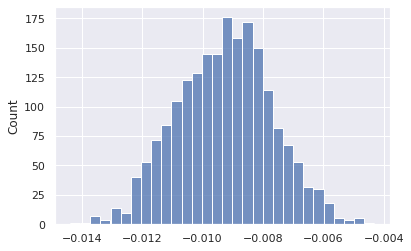

In [30]:
sns.histplot(ctr2 - ctr1)

Разница отрицательная: группа 2 показала хуже результат по CTR.

## Бакетное преобразования

In [31]:
q = """

SELECT exp_group, bucket,
    sum(likes)/sum(views) as bucket_ctr,
    quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group, 
        xxHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM simulator_20251220.feed_actions 
    WHERE toDate(time) between '2025-11-21' and '2025-11-27'
        and exp_group in (1,2)
    GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""

In [32]:

df = ph.read_clickhouse(q, connection=connection)


In [33]:
#тест Манна-Уитни видет разницу между группами
stats.mannwhitneyu(df[df.exp_group == 1].bucket_ctr, 
                   df[df.exp_group == 2].bucket_ctr, 
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

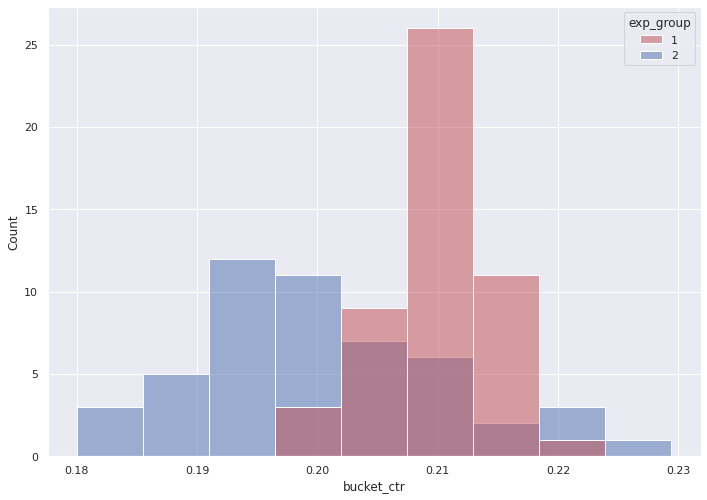

In [34]:
sns.set(rc={'figure.figsize': (11.7,8.27)})
groups=sns.histplot(data=df,
                    x='bucket_ctr',
                    hue='exp_group',
                    palette=['r','b'],
                    alpha=0.5,
                    kde=False)

По распределению видно,  что у группы 1 распределение CTR находится правее, новый алгоритм стал хуже чем было. 

In [35]:
# t-тест

stats.ttest_ind(df[df.exp_group == 1].bucket_ctr, 
                   df[df.exp_group == 2].bucket_ctr, 
                   equal_var = False)

Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)

t-тест показал , что 1 группа CTR больше

In [36]:
#тест Манна-Уитни 90 квантили
stats.mannwhitneyu(df[df.exp_group == 1].ctr9, 
                   df[df.exp_group == 2].ctr9, 
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=0.0, pvalue=6.7601631082665925e-18)

statistic=0.0- нет различий

# Вывод

## CTR группы 2 с новым алгоритмом ниже CTR контрольной группы 1
 t-тест: Разница между средними значениями групп очень мала. Распределение 2 группы бимодальное! из-за чего Ttest мог показать не верный результат;
 
 Mannwhitneyu: Более устойчив к выбросам и не требует предположения о нормальности данных.Существует статистически значимое различие в распределениях групп 1 и 2;
 
 Сглаженный CTR: t-тест показал Нет достаточных доказательств, чтобы утверждать, что средние значения двух групп действительно различаются(при сглаживании 2 группы, не полученно нормальное распределение), а Mannwhitneyu противоречивые результаты, что есть значимые различия распределений.

Пуассоновский бутстреп:Разница отрицательная: группа 2 показала хуже результат по CTR.
 
 Бакетное преобразование:t-тест показал , что CTR 1 группы больше, Mannwhitneyu - видет разницу между группами.

Т.к. у группы 2 не нормальное распределение, то скорее всего не стоит использовать t-тест. Результат Mannwhitneyu показывал , что разница есть между группами,  а с помощью Пуассоновский бутстрепа и Бакетного преобразования, видно что CTR 1 группы больше. 
В связи с этим, можно сделать вывод, что новый алгоритм не стоит раскатывать на всех пользователей. Возможно его можно доработать, т.к. в начале график CTR 2 группы стремительно растет, что говорит , что есть потенциал, но он не держит пользоватрелей.